In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("C:\\Users\\Prem\\Downloads\\churn_data.csv")
print(df.head())

   CustomerID  Gender  Tenure  MonthlyCharges        Contract  Churn
0           1    Male       1              29  Month-to-month      1
1           2  Female       5              56        One year      0
2           3    Male       2              45  Month-to-month      1
3           4  Female       8              78        Two year      0
4           5    Male      12              99        Two year      0


In [3]:
df.drop("CustomerID", axis=1, inplace=True)
df.dropna()

,Gender,Tenure,MonthlyCharges,Contract,Churn
0,Male,1,29,Month-to-month,1
1,Female,5,56,One year,0
2,Male,2,45,Month-to-month,1
3,Female,8,78,Two year,0
4,Male,12,99,Two year,0
5,Female,3,35,Month-to-month,1
6,Male,6,67,One year,0
7,Female,10,88,Two year,0
8,Male,4,54,Month-to-month,1
9,Female,9,73,One year,0


In [4]:
df = pd.get_dummies(df, drop_first=True)
#convert categorial into numeric

In [5]:
# Define Features & Target
X = df.drop("Churn", axis=1)   # Features
y = df["Churn"]                # Target

In [6]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
# Train Logistic Regression Model
model = LogisticRegression()

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [9]:
#Predictions
y_pred = model.predict(X_test)

In [10]:
#Model Evaluation
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))
# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
#Classification Report
print("Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.75
Confusion Matrix:
 [[2 0]
 [1 1]]
Report:
               precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      0.50      0.67         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4



In [11]:
# Predict Probability (Important for Churn)
y_prob = model.predict_proba(X_test)

# Probability of churn (class 1)
print(y_prob[:5])

[[0.04752996 0.95247004]
 [0.51788308 0.48211692]
 [0.96029199 0.03970801]
 [0.84459581 0.15540419]]


In [12]:
# Predict for New Customer
new_customer = X_test[0].reshape(1, -1)

prediction = model.predict(new_customer)
probability = model.predict_proba(new_customer)

print("Prediction:", prediction)
print("Churn Probability:", probability)

Prediction: [1]
Churn Probability: [[0.04752996 0.95247004]]


In [13]:
# mini project 2 product demand forecasting
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
# Create / Load Dataset

data = {
    "Month": [1,2,3,4,5,6,7,8,9,10,11,12],
    "Demand": [120,135,150,170,160,180,200,210,190,220,230,250]
}

df = pd.DataFrame(data)
print(df)

#Define Features & Target
X = df[["Month"]]   # Independent variable
y = df["Demand"]    # Target
# Train Linear Regression Model
model = LinearRegression()
model.fit(X, y)
#Predict Future Demand
# Predict for next 3 months:

future_months = pd.DataFrame({"Month": [13,14,15]})

predictions = model.predict(future_months)

print(predictions)

    Month  Demand
0       1     120
1       2     135
2       3     150
3       4     170
4       5     160
5       6     180
6       7     200
7       8     210
8       9     190
9      10     220
10     11     230
11     12     250
[253.78787879 264.43473193 275.08158508]


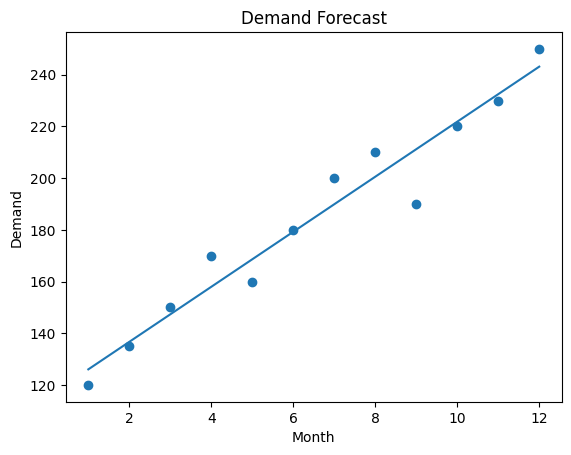

In [14]:
plt.scatter(X, y)
plt.plot(X, model.predict(X))
plt.xlabel("Month")
plt.ylabel("Demand")
plt.title("Demand Forecast")
plt.show()

In [17]:
# mini project 3 Customer Segmentation
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
data = {
    "CustomerID": [1,2,3,4,5,6,7,8,9,10],
    "AnnualIncome": [15,16,17,18,80,85,88,90,40,42],
    "SpendingScore": [39,81,6,77,40,76,6,94,50,60]
}

df = pd.DataFrame(data)
#Select Features
X = df[["AnnualIncome", "SpendingScore"]]
# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

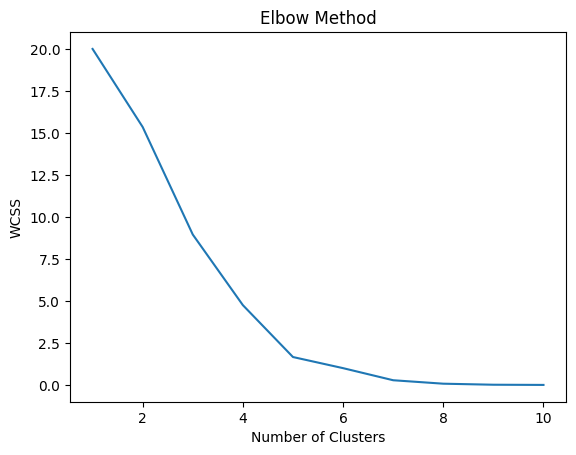

In [18]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

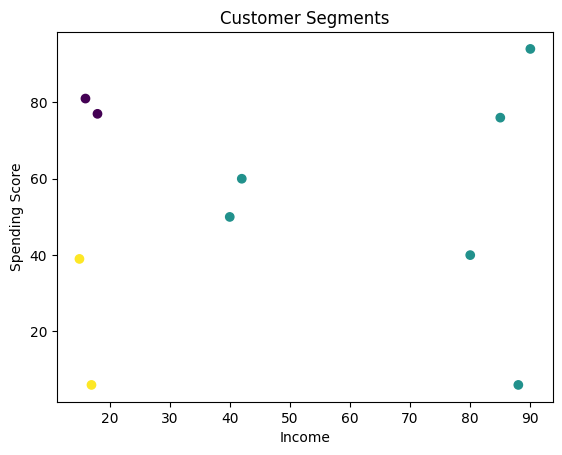

In [19]:
#Train K-Means Model
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)
# Visualize Clusters
plt.scatter(df["AnnualIncome"], df["SpendingScore"], c=df["Cluster"])
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.show()

High spenders 💰
Budget customers 🪙
Frequent buyers 🔁

In [24]:
# mini project 4 Sentiment Analysis

#Algorithm: Naive Bayes
#Goal: Classify reviews (Positive / Negative)

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 📂 2. Create Dataset (you can replace with CSV)
data = {
    "Review": [
        "I love this product",
        "This is amazing",
        "Worst experience ever",
        "I hate it",
        "Very good quality",
        "Not worth the money",
        "Excellent product",
        "Bad quality",
        "Super happy with purchase",
        "Terrible service"
    ],
    "Sentiment": [
        "Positive","Positive","Negative","Negative","Positive",
        "Negative","Positive","Negative","Positive","Negative"
    ]
}

df = pd.DataFrame(data)

# 🧹 3. Encode Labels (Important)
le = LabelEncoder()
df["Sentiment"] = le.fit_transform(df["Sentiment"])
# Positive = 1, Negative = 0

# 🎯 4. Features & Target
X = df["Review"]
y = df["Sentiment"]

# 🔢 5. Convert Text → Numbers (TF-IDF)
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(X)

# ✂️ 6. Train-Test Split (Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 🤖 7. Train Model
model = MultinomialNB()
model.fit(X_train, y_train)

# 🔮 8. Predictions
y_pred = model.predict(X_test)

# 📊 9. Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 🔍 10. Test Custom Inputs
samples = [
    "This product is very good",
    "I am extremely disappointed",
    "Worth every penny",
    "Worst purchase ever"
]

samples_vec = vectorizer.transform(samples)
predictions = model.predict(samples_vec)

# Convert back to labels
predicted_labels = le.inverse_transform(predictions)

print("\nPredictions:")
for text, label in zip(samples, predicted_labels):
    print(f"{text} → {label}")

Accuracy: 0.5

Confusion Matrix:
 [[0 1]
 [0 1]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2


Predictions:
This product is very good → Positive
I am extremely disappointed → Negative
Worth every penny → Negative
Worst purchase ever → Negative


c:\Users\Prem\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Prem\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Prem\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# mini project 3 Fraud Detection

Algorithm: Decision Tree
Goal: Detect fraudulent transactions (Fraud / Not Fraud)
Concept

A Decision Tree splits data based on conditions:

👉 Example:

If amount > 5000 → possible fraud
If location mismatch → fraud
🌳 Decision Tree Idea

𝐸
𝑛
𝑡
𝑟
𝑜
𝑝
𝑦
=
−
∑
𝑝
𝑖
log
⁡
2
𝑝
𝑖
Entropy=−∑p
i
	​

log
2
	​

p
i
	​


👉 Used to decide best split (information gain)


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

data = {
    "TransactionAmount": [100, 2000, 150, 5000, 300, 7000, 120, 9000, 250, 10000],
    "TransactionTime": [1, 5, 2, 10, 3, 12, 1, 15, 4, 18],
    "LocationChange": [0, 1, 0, 1, 0, 1, 0, 1, 0, 1],
    "IsFraud": [0, 0, 0, 1, 0, 1, 0, 1, 0, 1]
}

df = pd.DataFrame(data)
#Features & Target
X = df.drop("IsFraud", axis=1)
y = df["IsFraud"]
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# Train Decision Tree Model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
#Predictions
y_pred = model.predict(X_test)
#Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
#Test New Transaction
new_transaction = [[8000, 14, 1]]  # amount, time, location change

prediction = model.predict(new_transaction)

print("Fraud" if prediction[0] == 1 else "Not Fraud")

Accuracy: 1.0

Confusion Matrix:
 [[1 0]
 [0 1]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2

Fraud


c:\Users\Prem\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# mini project 6 House Price Prediction

Algorithm: Random Forest
Goal: Predict house prices

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, r2_score
data = {
    "Area": [1000, 1500, 2000, 2500, 3000, 1200, 1800, 2200, 2700, 3200],
    "Bedrooms": [2, 3, 3, 4, 4, 2, 3, 3, 4, 5],
    "Bathrooms": [1, 2, 2, 3, 3, 1, 2, 2, 3, 4],
    "Price": [200000, 300000, 400000, 500000, 600000,
              220000, 350000, 420000, 520000, 650000]
}

df = pd.DataFrame(data)
# Features & Target
X = df.drop("Price", axis=1)
y = df["Price"]
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Train Random Forest Model
model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X_train, y_train)
# Predictions
y_pred = model.predict(X_test)
# Evaluation
#RMSE (Error)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)
#R² Score
print("R2 Score:", r2_score(y_test, y_pred))
# Predict New House Price
new_house = [[2000, 3, 2]]  # Area, Bedrooms, Bathrooms

price = model.predict(new_house)

print("Predicted Price:", price[0])

RMSE: 16728.717822953437
R2 Score: 0.9768719008264463
Predicted Price: 386600.0


c:\Users\Prem\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


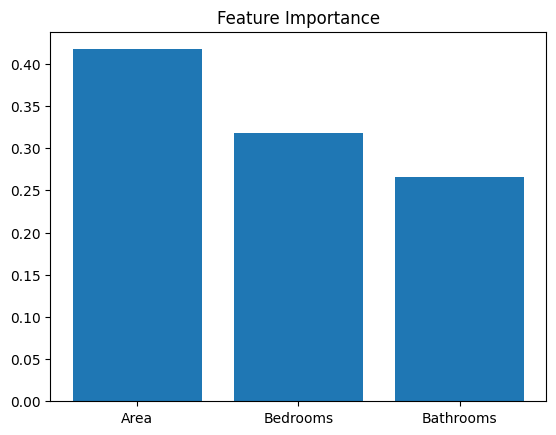

In [28]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

plt.bar(X.columns, importance)
plt.title("Feature Importance")
plt.show()

# mini project 7 Email Spam Detection

Algorithm: SVM (Support Vector Machine)
Goal: Classify emails → Spam / Not Spam

🧠 Concept

SVM finds the best boundary (hyperplane) to separate classes.

👉 Example:

“Win money now!!!” → Spam 🚨
“Meeting at 10 AM” → Not Spam ✅

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

data = {
    "Email": [
        "Win money now",
        "Limited offer just for you",
        "Meeting at 10 AM",
        "Project deadline tomorrow",
        "Congratulations you won a prize",
        "Let's catch up tomorrow",
        "Free lottery ticket",
        "Important business meeting"
    ],
    "Label": ["Spam","Spam","Not Spam","Not Spam","Spam","Not Spam","Spam","Not Spam"]
}

df = pd.DataFrame(data)
# Convert Labels to Numbers
df["Label"] = df["Label"].map({"Spam":1, "Not Spam":0})

# Text Vectorization (TF-IDF)  #TF-IDF = Term Frequency – Inverse Document Frequency
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(df["Email"])
y= df["Label"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# Train SVM Model
model = SVC(kernel='linear')

model.fit(X_train, y_train)
# Predictions
y_pred = model.predict(X_test)
#Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
# Test New Email
emails = [
    "You have won 1 crore prize",
    "Let's schedule a meeting",
    "Free offer just click now",
    "Project discussion tomorrow"
]

emails_vec = vectorizer.transform(emails)
predictions = model.predict(emails_vec)

for text, pred in zip(emails, predictions):
    print(text, "→", "Spam" if pred == 1 else "Not Spam")

Accuracy: 1.0

Confusion Matrix:
 [[1 0]
 [0 1]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2

You have won 1 crore prize → Spam
Let's schedule a meeting → Not Spam
Free offer just click now → Spam
Project discussion tomorrow → Not Spam


# project 8 Stock Trend Prediction

Algorithm: K-Nearest Neighbors (KNN)
Goal: Predict stock movement (UP 📈 / DOWN 📉)

🧠 Concept

KNN predicts based on similar past data

👉 Idea:

Find K nearest past days
Look at their movement
Majority decides prediction

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, classification_report
# Create Dataset (Sample Stock Data)
data = {
    "Open": [100,102,101,105,107,110,108,111,115,117],
    "Close": [102,101,105,107,110,108,111,115,117,116],
    "Volume": [1000,1200,1100,1500,1600,1400,1700,1800,2000,2100]
}

df = pd.DataFrame(data)
# Create Target (UP/DOWN)
df["Target"] = (df["Close"] > df["Open"]).astype(int)
# 1 = UP, 0 = DOWN
#Features & Target
X = df[["Open", "Close", "Volume"]]
y = df["Target"]
# Feature Scaling (IMPORTANT for KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
#Train KNN Model
model = KNeighborsClassifier(n_neighbors=3)

model.fit(X_train, y_train)
# Predictions
y_pred = model.predict(X_test)
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
# Predict New Stock Movement
new_data = [[120, 125, 2200]]  # Open, Close, Volume

new_scaled = scaler.transform(new_data)

prediction = model.predict(new_scaled)

print("UP 📈" if prediction[0] == 1 else "DOWN 📉")

Accuracy: 0.5
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2

UP 📈


c:\Users\Prem\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Prem\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Prem\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Prem\anaconda3\Lib\sit

# mini project 9 Credit Risk Prediction

Algorithm: Gradient Boosting
Goal: Predict loan default (Default / No Default)

🧠 Concept

Gradient Boosting builds models sequentially:

👉 Each new model:

Fixes errors of previous model
Improves accuracy step-by-step

In [31]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

data = {
    "Income": [30000, 50000, 40000, 80000, 20000, 90000, 35000, 70000, 25000, 100000],
    "LoanAmount": [10000, 20000, 15000, 30000, 5000, 35000, 12000, 25000, 8000, 40000],
    "CreditScore": [600, 700, 650, 750, 580, 780, 620, 720, 590, 800],
    "Default": [1, 0, 0, 0, 1, 0, 1, 0, 1, 0]
}

df = pd.DataFrame(data)
#Features & Target
X = df.drop("Default", axis=1)
y = df["Default"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train Gradient Boosting Model
model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Predict New Customer
new_customer = [[45000, 15000, 650]]  # Income, LoanAmount, CreditScore

prediction = model.predict(new_customer)

print("Default Risk" if prediction[0] == 1 else "No Default")

Accuracy: 1.0

Confusion Matrix:
 [[1 0]
 [0 1]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2

No Default


c:\Users\Prem\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


# mini project 10 Recommendation System

Algorithm: Collaborative Filtering
Goal: Recommend products to users

🧠 Concept

Collaborative Filtering recommends based on user behavior

👉 Idea:

“Users like you also liked this”
📊 Types
User-Based → similar users
Item-Based → similar items

In [ ]:

from sklearn.metrics.pairwise import cosine_similarity

data = {
    "User": ["A","A","A","B","B","C","C","D","D"],
    "Product": ["P1","P2","P3","P1","P4","P2","P3","P1","P4"],
    "Rating": [5,4,3,4,5,5,4,3,4]
}

df = pd.DataFrame(data)
#Create User-Item Matrix
matrix = df.pivot_table(index="User", columns="Product", values="Rating").fillna(0)
print(matrix)

#Compute Similarity
similarity = cosine_similarity(matrix)
similarity_df = pd.DataFrame(similarity, index=matrix.index, columns=matrix.index)
print(similarity_df)

# Recommend Products
def recommend(user):
    # Find similar users
    similar_users = similarity_df[user].sort_values(ascending=False)
    
    # Remove itself
    similar_users = similar_users.drop(user)
    
    # Most similar user
    top_user = similar_users.index[0]
    
    # Products rated by similar user
    products = matrix.loc[top_user]
    
    # Recommend products not already rated by current user
    user_products = matrix.loc[user]
    
    recommendations = products[user_products == 0]
    
    return recommendations.sort_values(ascending=False)
# Get Recommendations
print(recommend("A"))

Product   P1   P2   P3   P4
User                       
A        5.0  4.0  3.0  0.0
B        4.0  0.0  0.0  5.0
C        0.0  5.0  4.0  0.0
D        3.0  0.0  0.0  4.0
User         A         B         C         D
User                                        
A     1.000000  0.441726  0.706762  0.424264
B     0.441726  1.000000  0.000000  0.999512
C     0.706762  0.000000  1.000000  0.000000
D     0.424264  0.999512  0.000000  1.000000
Product
P4    0.0
Name: C, dtype: float64
